In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
from pathlib import Path
import os

BASE_DIR = Path(os.getcwd()).parent
RAW_DATA_PATH = (BASE_DIR / "data" / "raw").resolve()

In [3]:
train = pd.read_csv(RAW_DATA_PATH / "train.csv")
train.info()
train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
test = pd.read_csv(RAW_DATA_PATH / 'test.csv')
test.shape

(1459, 80)

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.isnull().sum()[train.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [7]:
test.isnull().sum()[test.isnull().sum() > 0]

MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64

In [8]:
for col in train.columns:
    print(col,train[col].unique()[len(train[col].unique()) < 25])

Id []
MSSubClass [[ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]]
MSZoning [['RL' 'RM' 'C (all)' 'FV' 'RH']]
LotFrontage []
LotArea []
Street [['Pave' 'Grvl']]
Alley [[nan 'Grvl' 'Pave']]
LotShape [['Reg' 'IR1' 'IR2' 'IR3']]
LandContour [['Lvl' 'Bnk' 'Low' 'HLS']]
Utilities [['AllPub' 'NoSeWa']]
LotConfig [['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']]
LandSlope [['Gtl' 'Mod' 'Sev']]
Neighborhood []
Condition1 [['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']]
Condition2 [['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']]
BldgType [['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']]
HouseStyle [['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']]
OverallQual [[ 7  6  8  5  9  4 10  3  1  2]]
OverallCond [[5 8 6 7 4 2 3 9 1]]
YearBuilt []
YearRemodAdd []
RoofStyle [['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']]
RoofMatl [['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
  'ClyTile']]
Exterior1st [['VinylSd' 'Metal

In [9]:
train.value_counts()

Series([], Name: count, dtype: int64)

In [10]:
MSSUBClass_labels = {
# num: levels, >2 lvl,  half-story, age,  finished,  PUD, duplex, split, 2fam,  attic 
    20:	['1',  'No',   'No',       'New', 'NA',     'No',  'No',   'No',  'No',  'No'],
    30: ['1',  'No',   'No',       'Old', 'NA',     'No',  'No',   'No',  'No',  'No'],
    40:	['1',  'No',   'No',       'All', 'NA',     'No',  'No',   'No',  'No',  'Yes'],
    45:	['1',  'No',   'Yes',      'All', 'No',     'No',  'No',   'No',  'No',  'No'],
    50:	['1',  'No',   'Yes',      'All', 'Yes',    'No',  'No',   'No',  'No',  'Yes'],
    60:	['2',  'No',   'No',       'New', 'NA',     'No',  'No',   'No',  'No',  'No'],
    70:	['2',  'No',   'No',       'Old', 'NA',     'No',  'No',   'No',  'No',  'No'],
    75:	['2',  'No',   'Yes',      'All', 'NA',     'No',  'No',   'No',  'No',  'No'],
    80:	['2', 'Yes',   'No',       'All', 'NA',     'No',  'No',   'Yes', 'No',  'No'], # attic yes or no
    85:	['2',  'No',   'No',       'All', 'NA',     'No',  'No',   'Yes', 'No',  'No'],
    90:	['2',  'No',   'No',       'All', 'NA',     'No',  'Yes',  'No',  'No',  'No'],
    120:['1',  'No',   'No',       'New', 'NA',     'Yes', 'No',   'No',  'No',  'No'],
    150:['1',  'No',   'Yes',      'All', 'NA',     'Yes', 'No',   'No',  'No',  'No'],
    160:['2',  'No',   'No',       'New', 'NA',     'Yes', 'No',   'No',  'No',  'No'],
    180:['2',  'Yes',  'No',       'All', 'NA',     'Yes', 'No',   'Yes', 'No',  'No'],
    190:['2',  'No',   'No',       'All', 'NA',     'No',  'No',   'No', 'Yes',  'No'],
}

MSSUBClass_cols = {
0: "levels",
1: "gt2lvl",
2: "half_story",
3: "age",
4: "finished",
5: "pud",
6: "duplex",
7: "split",
8: "two_family",
9: "attic"
}

features = train["MSSubClass"].map(MSSUBClass_labels).apply(pd.Series)
features.rename(columns=MSSUBClass_cols, inplace=True)
train = pd.concat([train, features], axis=1)
train.drop(['MSSubClass'],axis=1,inplace=True)

features = test["MSSubClass"].map(MSSUBClass_labels).apply(pd.Series)
features.rename(columns=MSSUBClass_cols, inplace=True)
test = pd.concat([test, features], axis=1)
test.drop(['MSSubClass'],axis=1,inplace=True)

In [11]:
MSZoning_rep = {
    'A':  {"zone_type": "Agriculture",       "density": "NA"},
    'C':  {"zone_type": "Commercial",        "density": "NA"},
    'FV': {"zone_type": "Floating Village",  "density": "NA"},
    'I':  {"zone_type": "Industrial",        "density": "NA"},
    'RH': {"zone_type": "Residential",       "density": "High"},
    'RL': {"zone_type": "Residential",       "density": "Low"},
    'RP': {"zone_type": "Residential Park",  "density": "Low"},
    'RM': {"zone_type": "Residential",       "density": "Med"},
}

features = train["MSZoning"].map(MSZoning_rep).fillna({}).apply(pd.Series)
train = pd.concat([train, features], axis=1)
train.drop(['MSZoning'],axis=1,inplace=True)

features = test["MSZoning"].map(MSZoning_rep).fillna({}).apply(pd.Series)
test = pd.concat([test, features], axis=1)
test.drop(['MSZoning'],axis=1,inplace=True)

In [12]:
Utilities_rep = {
    "AllPub": {"electricity":"Yes", "gas":"Yes", "water":"Yes", "sewer":"Yes"},
    "NoSewr": {"electricity":"Yes", "gas":"Yes", "water":"Yes", "sewer":"No"},
    "NoSeWa": {"electricity":"Yes", "gas":"Yes", "water":"No",  "sewer":"No"},
    "ELO":    {"electricity":"Yes", "gas":"No",  "water":"No",  "sewer":"No"},
}

features = train["Utilities"].map(Utilities_rep).fillna({}).apply(pd.Series)
train = pd.concat([train, features], axis=1)
train.drop("Utilities", axis=1, inplace=True)

features = test["Utilities"].map(Utilities_rep).fillna({}).apply(pd.Series)
test = pd.concat([test, features], axis=1)
test.drop("Utilities", axis=1, inplace=True)

In [13]:
# Label present in BldgType
train.drop(['two_family','duplex'],axis=1,inplace=True)
test.drop(['two_family','duplex'],axis=1,inplace=True)

In [14]:
# Label present in HouseStyle
train.drop(['split'],axis=1,inplace=True)
test.drop(['split'],axis=1,inplace=True)

In [15]:
# Overall score harmonic mean of both
# NOTE mult maybe
train['OverallScore'] = 2*train['OverallCond']*train['OverallQual']/(train['OverallCond']+train['OverallQual'])
test['OverallScore'] = 2*test['OverallCond']*test['OverallQual']/(test['OverallCond']+test['OverallQual'])

In [16]:
# surface area
train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
test["TotalSF"]  = test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"]

In [17]:
# bathroom count
train["TotalBathrooms"] = (
    train["FullBath"]
    + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"]
    + 0.5 * train["BsmtHalfBath"]
)

test["TotalBathrooms"] = (
    test["FullBath"]
    + 0.5 * test["HalfBath"]
    + test["BsmtFullBath"]
    + 0.5 * test["BsmtHalfBath"]
)

In [18]:
porch_cols = [
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "WoodDeckSF"
]

train["TotalPorchSF"] = train[porch_cols].fillna(0).sum(axis=1)
test["TotalPorchSF"] = test[porch_cols].fillna(0).sum(axis=1)

train["HasPorch"] = (train["TotalPorchSF"] > 0).astype(bool)
test["HasPorch"] = (test["TotalPorchSF"] > 0).astype(bool)

In [19]:
qual_map = {
    "Ex":5,
    "Gd":4,
    "TA":3,
    "Fa":2,
    "Po":1,
    "NA":0
}

for col in ["BsmtQual","GarageQual","KitchenQual"]:
    train[col+"_num"] = train[col].map(qual_map)
    test[col+"_num"] = test[col].map(qual_map)

train["SpaceQualityScore"] = (
    train["BsmtQual_num"].fillna(0) * train["TotalBsmtSF"].fillna(0) +
    train["OverallQual"].fillna(0) * (train["1stFlrSF"].fillna(0) + train["2ndFlrSF"].fillna(0)) +
    train["GarageQual_num"].fillna(0) * train["GarageArea"].fillna(0)
) / ((train["TotalSF"].fillna(0) + train["GarageArea"].fillna(0)).replace(0,1))

test["SpaceQualityScore"] = (
    test["BsmtQual_num"].fillna(0) * test["TotalBsmtSF"].fillna(0) +
    test["OverallQual"].fillna(0) * (test["1stFlrSF"].fillna(0) + test["2ndFlrSF"].fillna(0)) +
    test["GarageQual_num"].fillna(0) * test["GarageArea"].fillna(0)
) / ((test["TotalSF"].fillna(0) + test["GarageArea"].fillna(0)).replace(0,1))

In [20]:
# Have YearBuilt
train.drop(["age"],axis=1,inplace=True)
test.drop(["age"],axis=1,inplace=True)
# train["age"][train.YearBuilt <= 1945] = "Old"
# train["age"][train.YearBuilt > 1945] = "New"

train['SoldAfter'] = train['YrSold']-train['YearBuilt']
test['SoldAfter'] = test['YrSold']-test['YearBuilt']

# Time since renovation
train["TTRenovation"] = train["YrSold"] - train[["YearBuilt","YearRemodAdd"]].max(axis=1)
test["TTRenovation"] = test["YrSold"] - test[["YearBuilt","YearRemodAdd"]].max(axis=1)


In [21]:
train.drop([0],axis=1,inplace=True)
test.drop([0],axis=1,inplace=True)

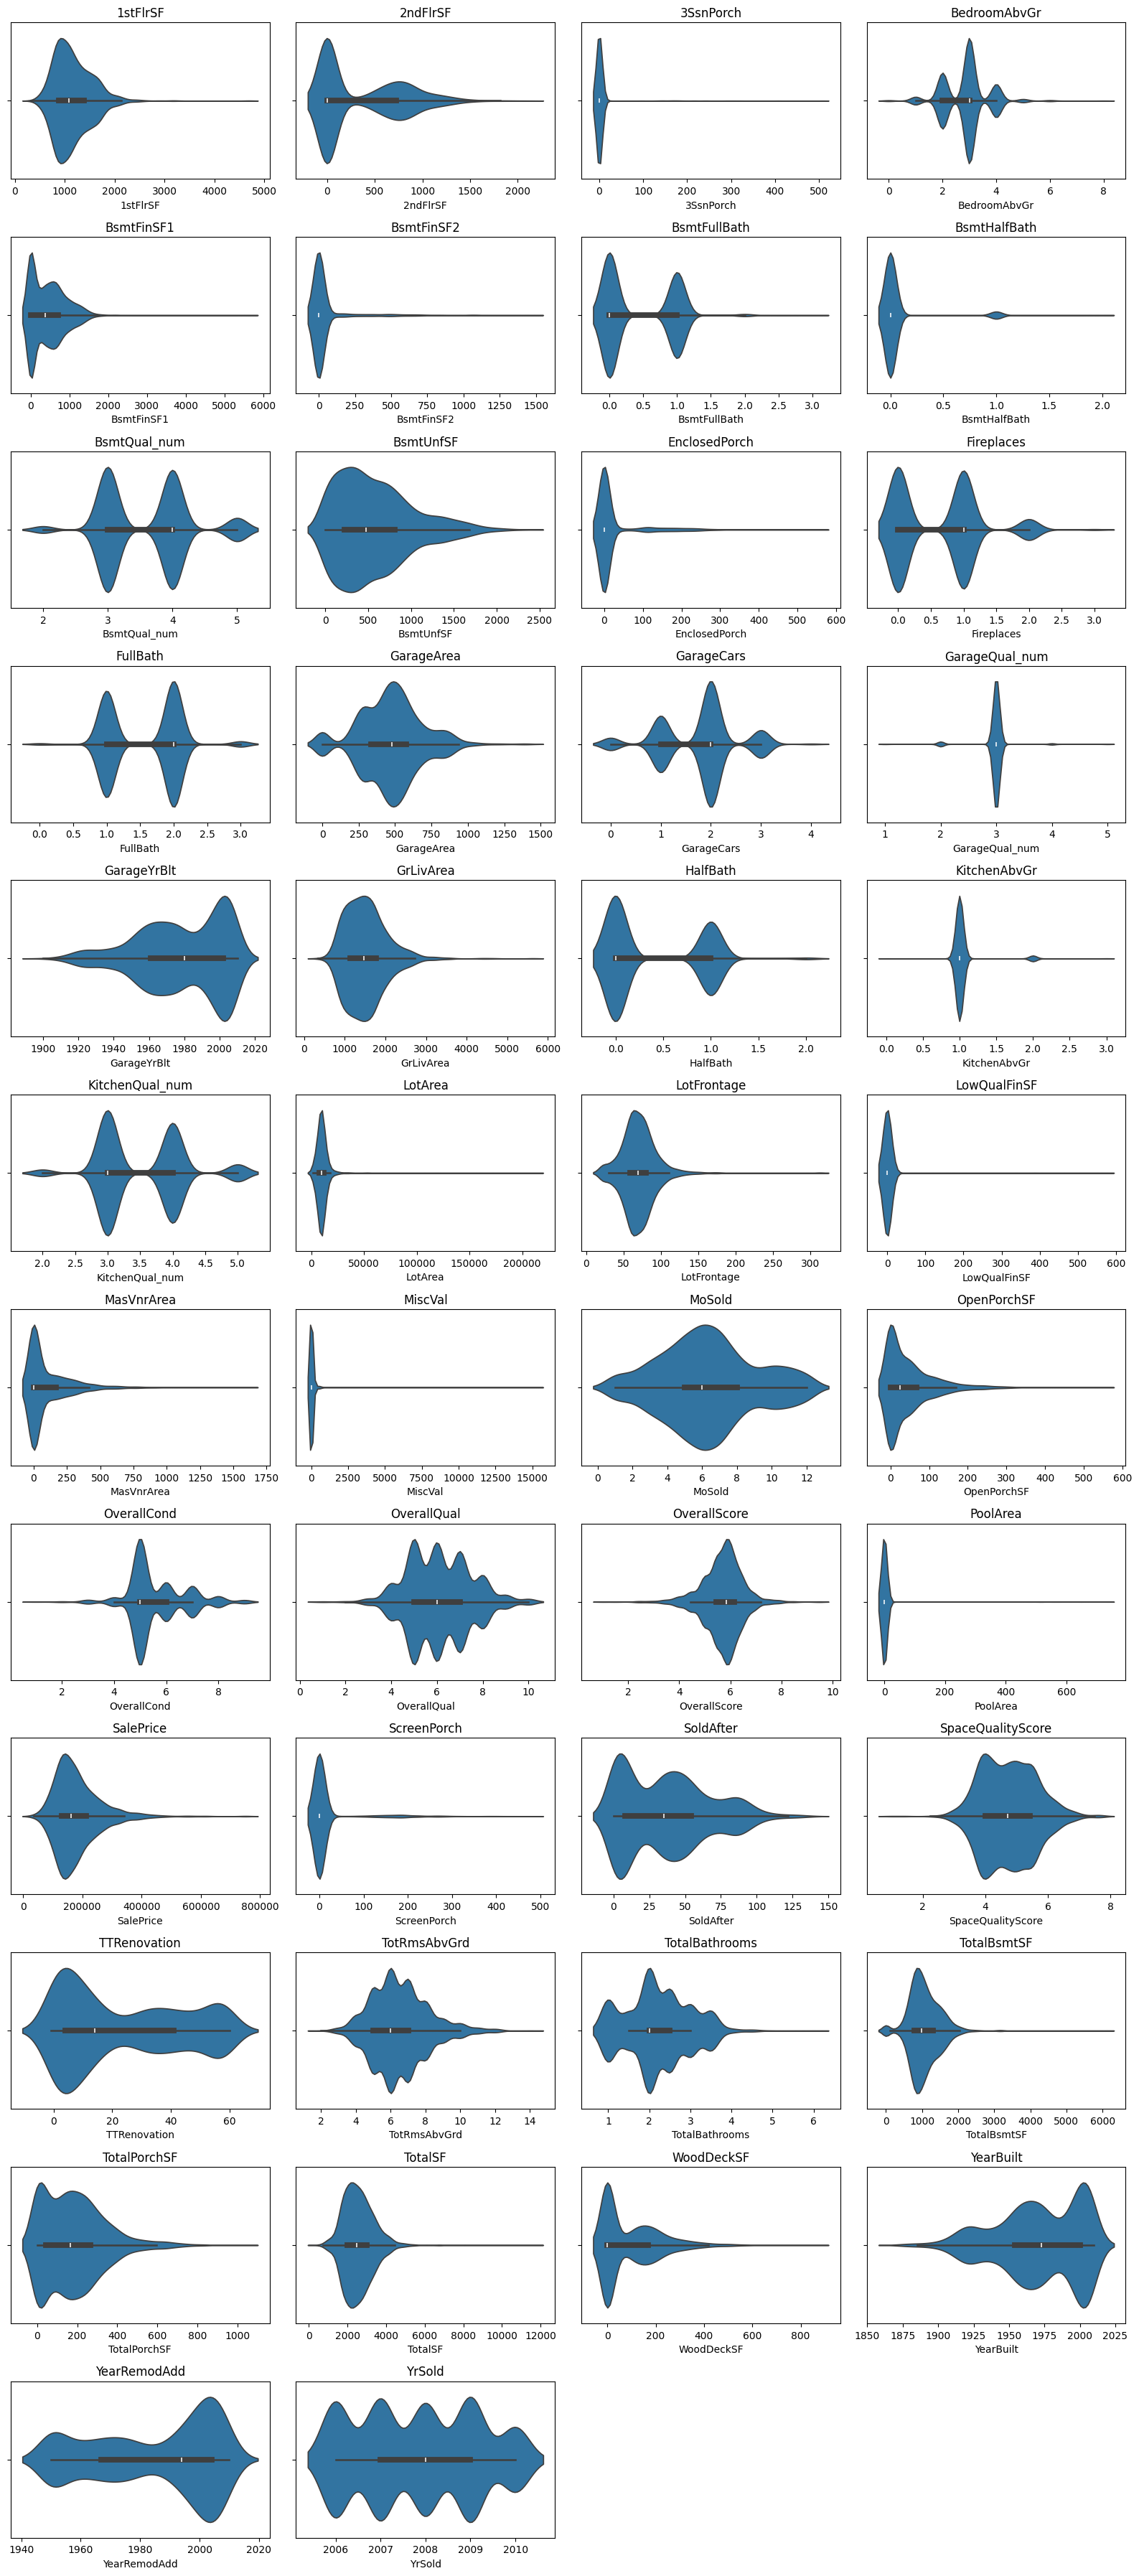

In [22]:
num_cols = train.select_dtypes(include=[np.number]).columns.difference(['Id'])
valid_cols = [c for c in num_cols if train[c].dropna().nunique() > 1]

n_cols = 4
n_rows = math.ceil(len(valid_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(valid_cols):
    sns.violinplot(x=train[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Total size:  46


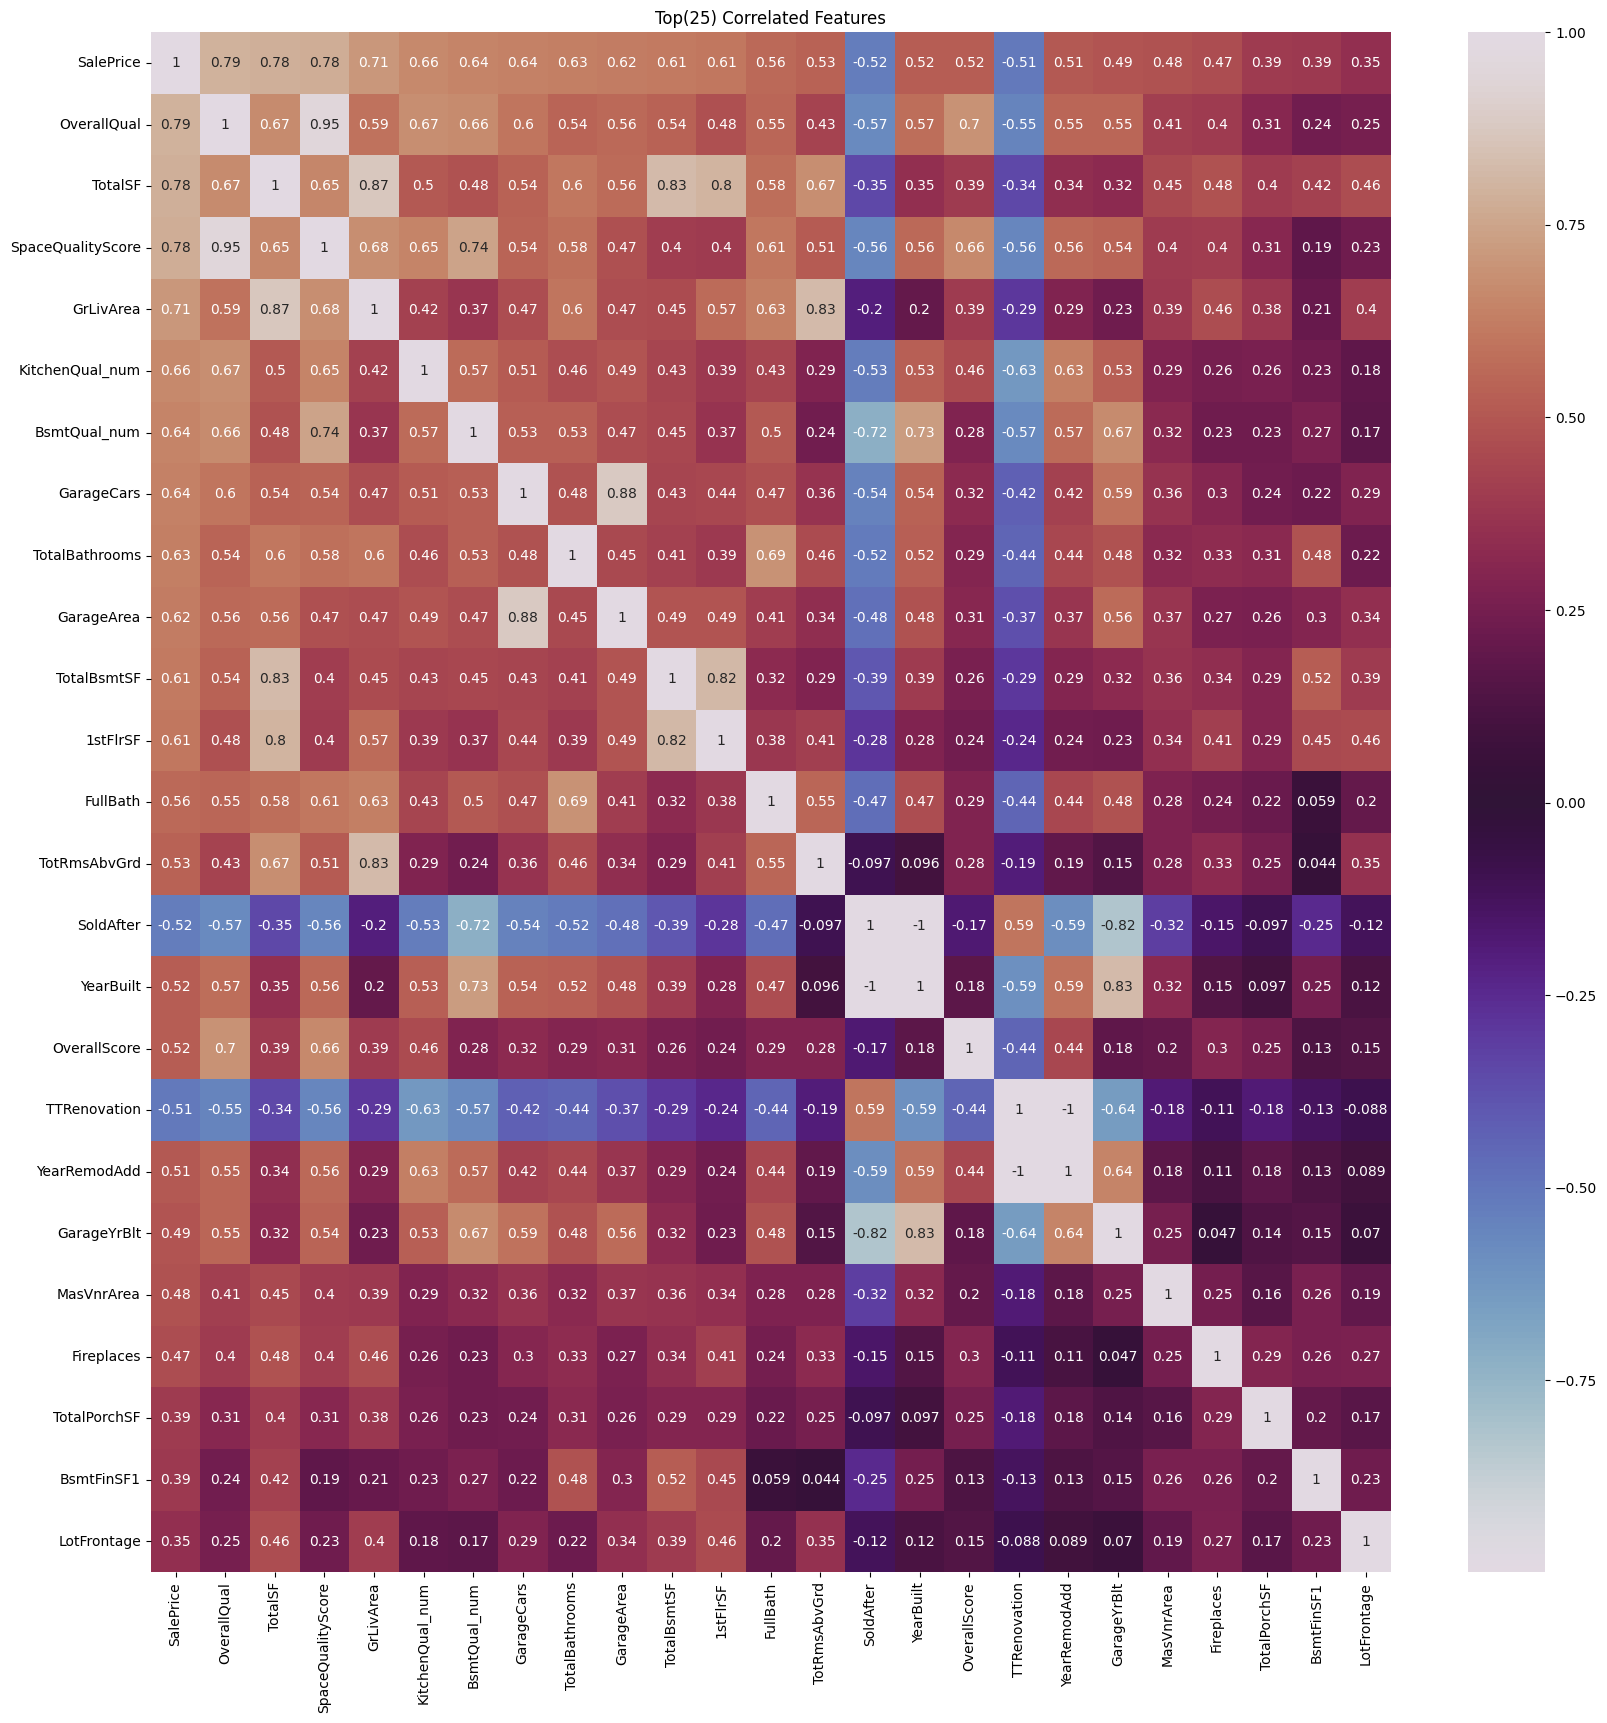

In [23]:
corr = train[num_cols].corr()["SalePrice"].abs().sort_values(ascending=False)
print('Total size: ',len(corr))

top_cols = corr.head(25).index
corr_matrix = train[top_cols].corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot=True, cmap="twilight", center=0)
plt.title("Top(25) Correlated Features")
plt.show()

In [24]:
train[num_cols].corr()["SalePrice"].abs().sort_values(ascending=False)

SalePrice            1.000000
OverallQual          0.790982
TotalSF              0.782260
SpaceQualityScore    0.780681
GrLivArea            0.708624
KitchenQual_num      0.659600
BsmtQual_num         0.644019
GarageCars           0.640409
TotalBathrooms       0.631731
GarageArea           0.623431
TotalBsmtSF          0.613581
1stFlrSF             0.605852
FullBath             0.560664
TotRmsAbvGrd         0.533723
SoldAfter            0.523350
YearBuilt            0.522897
OverallScore         0.518387
TTRenovation         0.509079
YearRemodAdd         0.507101
GarageYrBlt          0.486362
MasVnrArea           0.477493
Fireplaces           0.466929
TotalPorchSF         0.390993
BsmtFinSF1           0.386420
LotFrontage          0.351799
WoodDeckSF           0.324413
2ndFlrSF             0.319334
OpenPorchSF          0.315856
HalfBath             0.284108
LotArea              0.263843
BsmtFullBath         0.227122
BsmtUnfSF            0.214479
BedroomAbvGr         0.168213
GarageQual

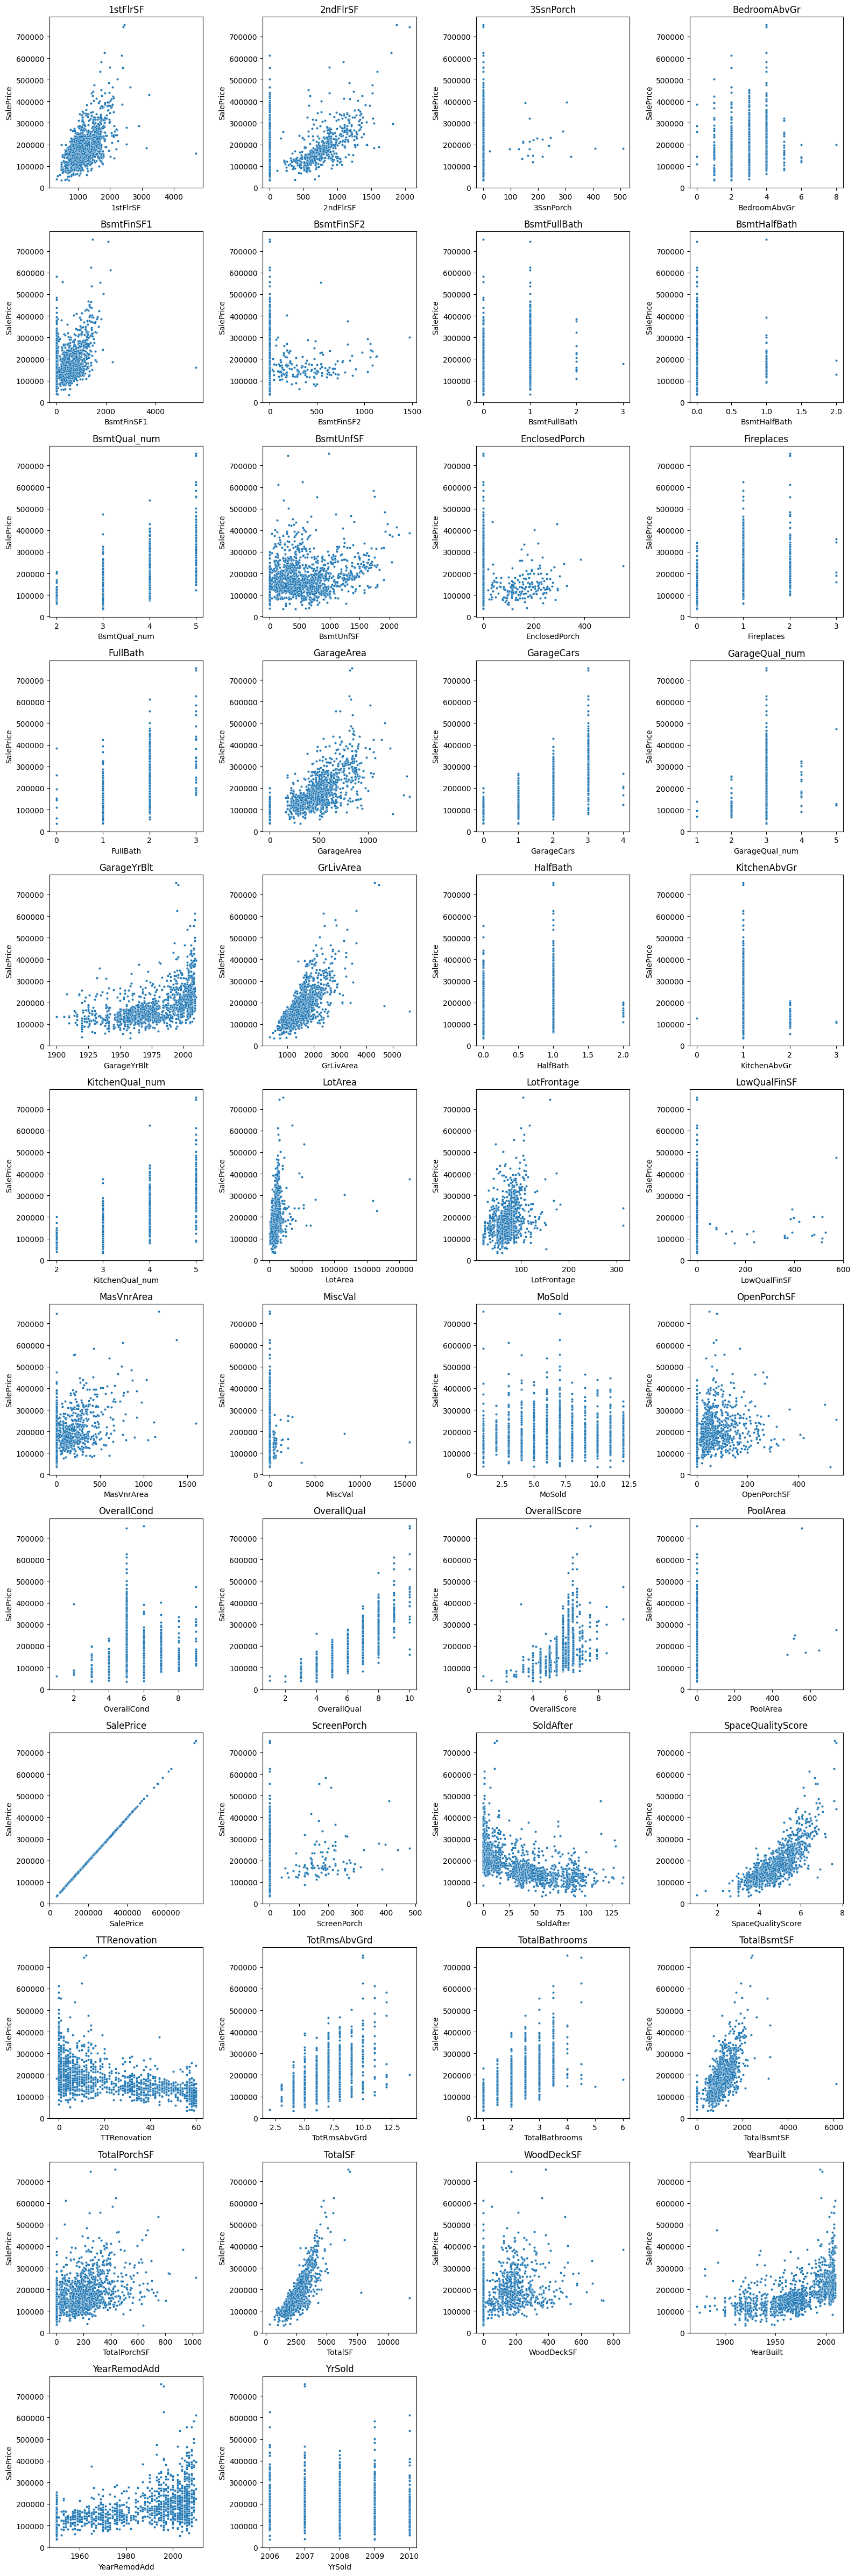

In [25]:
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=train[col], y=train["SalePrice"], ax=axes[i], s=10)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

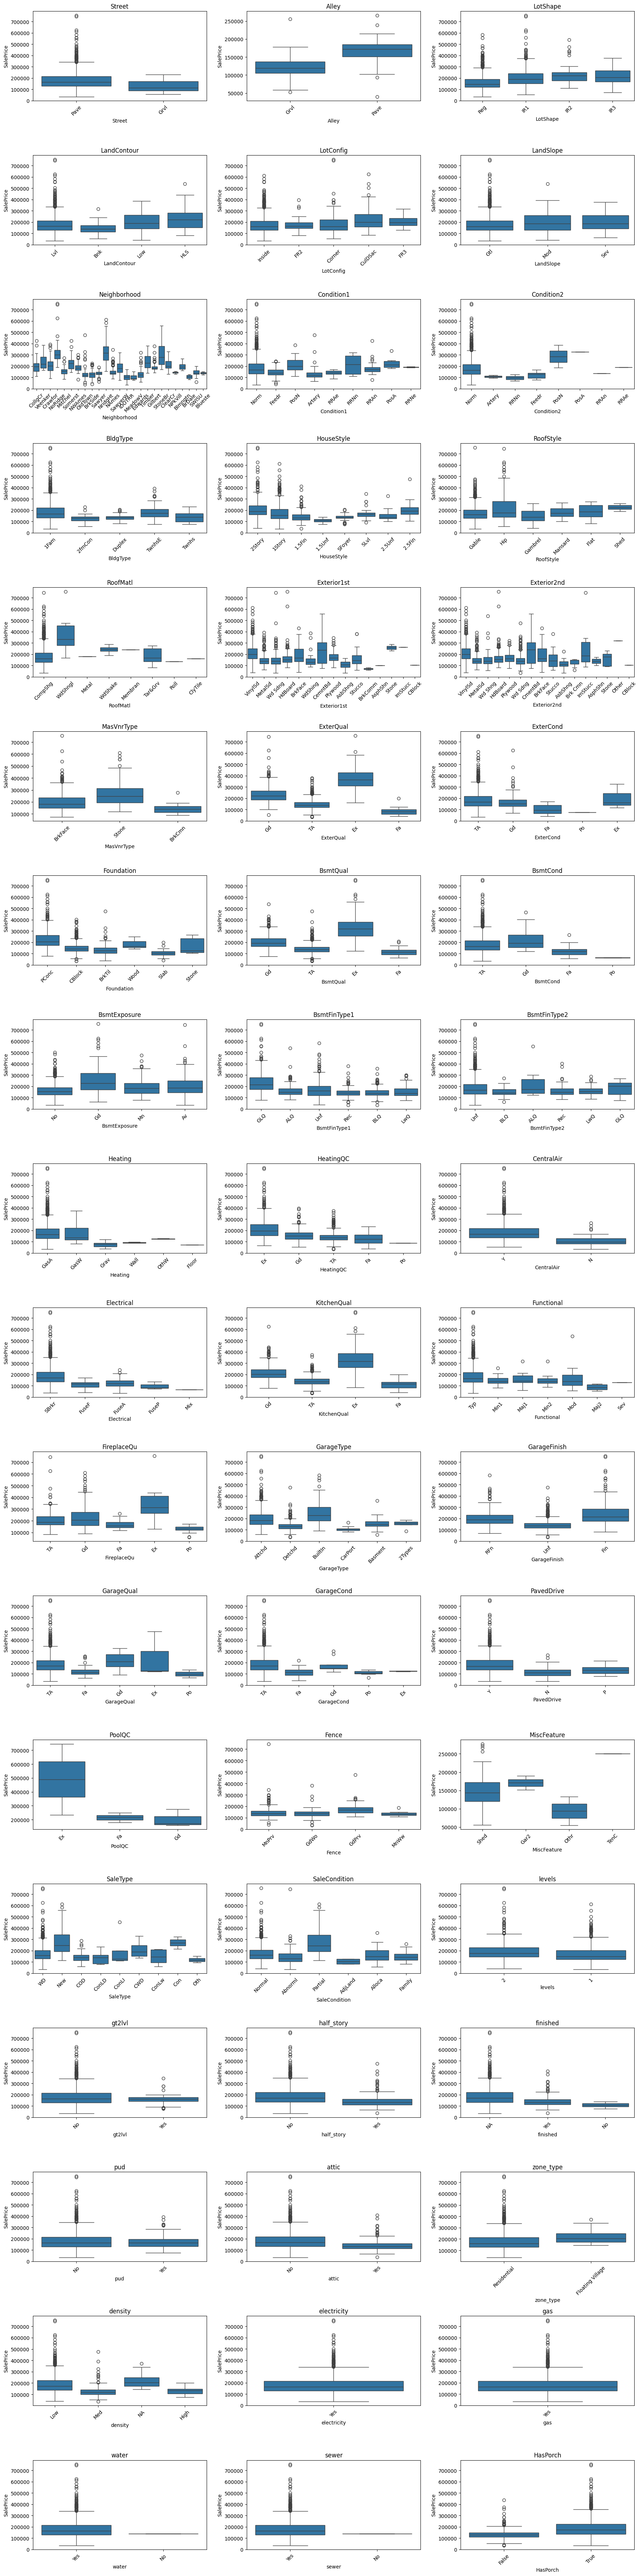

In [26]:
cat_cols = train.select_dtypes(exclude=[np.number]).columns

n_cols = 3
n_plots = len(cat_cols)
n_rows = (n_plots + n_cols - 1) // n_cols   # exact rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=train[col], y=train["SalePrice"], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

# remove unused axes
for ax in axes[n_plots:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [27]:
test.select_dtypes(include=[np.number]).isnull().sum() [test.select_dtypes(include=[np.number]).isnull().sum() > 0]

LotFrontage        227
MasVnrArea          15
BsmtFinSF1           1
BsmtFinSF2           1
BsmtUnfSF            1
TotalBsmtSF          1
BsmtFullBath         2
BsmtHalfBath         2
GarageYrBlt         78
GarageCars           1
GarageArea           1
TotalSF              1
TotalBathrooms       2
BsmtQual_num        44
GarageQual_num      78
KitchenQual_num      1
dtype: int64

In [28]:
train.select_dtypes(include=[np.number]).isnull().sum() [train.select_dtypes(include=[np.number]).isnull().sum() > 0]

LotFrontage       259
MasVnrArea          8
GarageYrBlt        81
BsmtQual_num       37
GarageQual_num     81
dtype: int64

In [29]:
train["LotFrontage"] = train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

test["LotFrontage"] = test.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [30]:
num_cols = train.select_dtypes(include=[np.number]).columns.difference(["SalePrice"])
skew = train[num_cols].skew().sort_values(ascending=False)
skewed_cols = skew[skew > 0.75].index

for col in skewed_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col]) 

train["SalePrice"] = np.log1p(train['SalePrice'])

In [31]:
train[num_cols] = train[num_cols].fillna(0)
test[num_cols] = test[num_cols].fillna(0)

In [32]:
cat_cols = train.select_dtypes(include=object).columns

train[cat_cols] = train[cat_cols].fillna("None")
test[cat_cols] = test[cat_cols].fillna("None")

In [33]:
train.isna().sum()[train.isna().sum()>0]
test.isna().sum()[test.isna().sum()>0]

Series([], dtype: int64)

In [34]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

train, test = train.align(test, join="left", axis=1, fill_value=0)
test.drop(['SalePrice'], axis=1, inplace=True)

In [35]:
# prevents unsafe JSON characters, avoid catboost errors 
import re

train.columns = [re.sub('[^A-Za-z0-9_]+', '_', c) for c in train.columns]
test.columns  = [re.sub('[^A-Za-z0-9_]+', '_', c) for c in test.columns]

In [36]:
Path(BASE_DIR / "data" / "processed").mkdir(parents=True, exist_ok=True)
train.to_csv(BASE_DIR / "data" / 'processed' / 'train.csv', index=False)
test.to_csv(BASE_DIR / "data" / 'processed' / 'test.csv', index=False)